# BV Similarity to THINGS as Kids Age

**Goal:** Plot how BabyView (BV) object representations become more (or less) similar to THINGS representations with age. X-axis = age (or age bin), Y-axis = similarity to THINGS.

## Data heterogeneity and how we compare RDMs

BV has different overlapping categories with THINGS at different ages (e.g. fewer categories with data in younger bins). To compare fairly:

1. **Canonical category order:** We define a single **ordered list of categories** (e.g. from the same `category_order_reorganized.txt` as notebook 07, or THINGS ∩ allowed). Every RDM is built so that **row/column index `i` always corresponds to `ordered_categories[i]`**. So the BV RDM and the THINGS RDM use the **same semantic ordering**: position (i, j) = distance between the same category pair in both matrices.

2. **Comparing the proper subset:** For each age bin, BV has data only for a subset of categories. When we correlate BV vs THINGS we use **only the intersection**: categories that have data in **both** (BV for that bin) **and** (THINGS). We extract the sub-RDM for those categories from both matrices using the **same indices** from `ordered_categories`, so the two sub-RDMs are aligned—entry (p, q) in both refers to the same pair of categories. We then compute Spearman correlation on the upper triangle of this common subset.

3. **Two similarity metrics:**
   - **RDM correlation (structure):** For each age bin we build the BV RDM with the same `ordered_categories` (NaN for categories with no data in that bin). We correlate the upper triangle of BV with THINGS **on the common subset only**, so we're always comparing the same category pairs.
   - **Mean category-wise correlation (first-order):** Same shared subset; for each category we correlate BV centroid with THINGS vector, then average.

Both metrics are reported and plotted so you can compare developmental trends.

## Setup and configuration

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr, pearsonr
from collections import defaultdict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Paths (relative to this notebook in analysis/individual_analyses/)
SCRIPT_DIR = Path(".").resolve()
PROJECT_ROOT = SCRIPT_DIR.parent.parent
# All plots from this notebook saved here
PLOTS_OUTPUT_DIR = SCRIPT_DIR / "bv_similarity_to_things_plots"
PLOTS_OUTPUT_DIR.mkdir(exist_ok=True)

# BV: normalized embeddings by subject and age (same as notebook 07)
NORMALIZED_EMBEDDINGS_DIR = Path("/data2/dataset/babyview/868_hours/outputs/yoloe_cdi_embeddings/clip_embeddings_grouped_by_age-mo_filtered-0.27_normalized")

# THINGS: one vector per category (same 163-cat space as BV). Prefer filtered/zscored if available.
THINGS_CSV_CLIP = SCRIPT_DIR / "../vss-2026/bv_things_comp_03012026/things_clip_filtered_zscored_hierarchical_threshold-0.27_163cats/normalized_filtered_embeddings_alphabetical.csv"
THINGS_CSV_DINOV3 = SCRIPT_DIR / "../vss-2026/bv_things_comp_03012026/things_dinov3_filtered_zscored_hierarchical_threshold-0.27_163cats/normalized_filtered_embeddings_alphabetical.csv"
# Fallback: raw THINGS from data/ (category column may be 'text' or index)
THINGS_CSV_FALLBACK_CLIP = PROJECT_ROOT / "data/things_clip_embeddings.csv"

CATEGORIES_FILE = PROJECT_ROOT / "data/things_bv_overlap_categories_exclude_zero_precisions.txt"
EXCLUDED_SUBJECT = "00270001"
MIN_CATEGORIES_FOR_RDM = 8
AGE_BIN_SIZE_MONTHS = 3  # e.g. 6–8, 9–11, ...

# Restrict analyses to subjects with enough data (≥MIN_AGE_BINS_FOR_TREND with valid similarity)?
# Recommended True: avoids mixing subjects with very different category/age coverage in aggregate and n-subjects plots.
USE_ONLY_SUBJECTS_WITH_TRAJECTORY = True
# For "similarity vs number of subjects": how many random subsets of size k to average over per (bin, k)
N_SAMPLES_FOR_N_SUBJECTS = 40

# Canonical category order for RDM alignment (same order for BV and THINGS; must match notebook 07 if comparing).
USE_PREDEFINED_CATEGORY_ORDER = True
PREDEFINED_CATEGORY_ORDER_PATH = SCRIPT_DIR / "../vss-2026/bv_things_comp_12252025/bv_clip_filtered_zscored_hierarchical_threshold-0.27_163cats/category_order_reorganized.txt"

# Detect embedding type from BV path
if "dinov3" in str(NORMALIZED_EMBEDDINGS_DIR).lower() or "dinov" in str(NORMALIZED_EMBEDDINGS_DIR).lower():
    EMBEDDING_TYPE = "dinov3"
    THINGS_CSV = THINGS_CSV_DINOV3 if THINGS_CSV_DINOV3.exists() else None
else:
    EMBEDDING_TYPE = "clip"
    THINGS_CSV = THINGS_CSV_CLIP if THINGS_CSV_CLIP.exists() else THINGS_CSV_FALLBACK_CLIP

if THINGS_CSV is None or not THINGS_CSV.exists():
    if EMBEDDING_TYPE == "clip" and THINGS_CSV_FALLBACK_CLIP.exists():
        THINGS_CSV = THINGS_CSV_FALLBACK_CLIP
    else:
        raise FileNotFoundError("THINGS CSV not found. Set THINGS_CSV to a path with one row per category.")

print(f"BV embeddings: {NORMALIZED_EMBEDDINGS_DIR}")
print(f"Embedding type: {EMBEDDING_TYPE}")
print(f"THINGS CSV: {THINGS_CSV} (exists: {THINGS_CSV.exists()})")
print(f"Age bin size: {AGE_BIN_SIZE_MONTHS} months")
print(f"Plots saved to: {PLOTS_OUTPUT_DIR}")
print(f"Canonical category order: {'predefined file' if USE_PREDEFINED_CATEGORY_ORDER and PREDEFINED_CATEGORY_ORDER_PATH and Path(PREDEFINED_CATEGORY_ORDER_PATH).exists() else 'THINGS ∩ allowed (sorted)'}")
print(f"Use only subjects with trajectory: {USE_ONLY_SUBJECTS_WITH_TRAJECTORY}")

BV embeddings: /data2/dataset/babyview/868_hours/outputs/yoloe_cdi_embeddings/clip_embeddings_grouped_by_age-mo_filtered-0.27_normalized
Embedding type: clip
THINGS CSV: /home/j7yang/babyview-projects/vss2026/object-detection/data/things_clip_embeddings.csv (exists: True)
Age bin size: 3 months
Plots saved to: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/bv_similarity_to_things_plots
Canonical category order: THINGS ∩ allowed (sorted)
Use only subjects with trajectory: True


## Load allowed categories and BV embeddings by age

In [3]:
def load_allowed_categories(path):
    if path is None or not Path(path).exists():
        return None
    with open(path) as f:
        return set(line.strip() for line in f if line.strip())

allowed_categories = load_allowed_categories(CATEGORIES_FILE)
print(f"Allowed categories: {len(allowed_categories) if allowed_categories else 'all'}")

def load_bv_embeddings_by_age(embeddings_dir, allowed_categories=None, excluded_subject=None, age_bin_size=1):
    """
    Load BV embeddings. Returns:
      subject_age_embeddings[subject_id][age_mo][category] = embedding (1D array).
    Uses exact age (no binning here; we bin when aggregating).
    """
    subject_age_embeddings = defaultdict(lambda: defaultdict(dict))
    category_folders = [f for f in embeddings_dir.iterdir() if f.is_dir()]
    if allowed_categories:
        category_folders = [f for f in category_folders if f.name in allowed_categories]
    for category_folder in tqdm(category_folders, desc="Loading BV by age"):
        cat = category_folder.name
        for emb_file in category_folder.glob("*.npy"):
            stem = emb_file.stem
            parts = stem.split("_")
            if len(parts) < 2:
                continue
            subject_id, age_str = parts[0], parts[1]
            if excluded_subject and subject_id == excluded_subject:
                continue
            try:
                age_mo = int(age_str)
            except ValueError:
                continue
            try:
                emb = np.load(emb_file)
                subject_age_embeddings[subject_id][age_mo][cat] = np.asarray(emb, dtype=np.float64).flatten()
            except Exception:
                continue
    return dict(subject_age_embeddings)

subject_age_embeddings = load_bv_embeddings_by_age(
    NORMALIZED_EMBEDDINGS_DIR,
    allowed_categories=allowed_categories,
    excluded_subject=EXCLUDED_SUBJECT,
)

all_ages = []
for _sid, age_data in subject_age_embeddings.items():
    all_ages.extend(age_data.keys())
print(f"Loaded {len(subject_age_embeddings)} subjects; age range {min(all_ages)}–{max(all_ages)} months")

Allowed categories: 163


Loading BV by age: 100%|██████████| 163/163 [00:01<00:00, 146.05it/s]

Loaded 31 subjects; age range 6–37 months


## Canonical category order (same for BV and THINGS RDMs)

We define **one ordered list** so that every RDM has the same row/column meaning: position `i` = `ordered_categories[i]`. Both the THINGS RDM and each age-bin BV RDM are built with this order; when we correlate, we take the **intersection** of categories present in that bin with THINGS and extract the same rows/columns from both matrices.

In [4]:
# Canonical ordered_categories is now defined in the 'Load THINGS category embeddings' cell below.
# Run that cell to define things_embeddings and ordered_categories.

## Load THINGS category embeddings

In [5]:
def load_things_embeddings(csv_path, category_col=None):
    """Load THINGS: dict category -> 1D embedding. csv_path: index or first column = category."""
    df = pd.read_csv(csv_path, index_col=0)
    if category_col and category_col in df.columns:
        df = df.set_index(category_col)
    # Index is category name; normalize to lowercase to match BV/category list
    things = {str(idx).strip().lower(): df.loc[idx].values.astype(np.float64) for idx in df.index}
    return things

things_embeddings = load_things_embeddings(THINGS_CSV)
print(f"THINGS categories: {len(things_embeddings)}")
if things_embeddings:
    first_cat = next(iter(things_embeddings))
    print(f"  Example '{first_cat}' shape: {things_embeddings[first_cat].shape}")

# Canonical category order: same for both BV and THINGS RDMs (row/col i = ordered_categories[i])
things_set = set(things_embeddings.keys())
if USE_PREDEFINED_CATEGORY_ORDER and PREDEFINED_CATEGORY_ORDER_PATH and Path(PREDEFINED_CATEGORY_ORDER_PATH).exists():
    with open(PREDEFINED_CATEGORY_ORDER_PATH) as f:
        ordered_categories = [line.strip() for line in f if line.strip() and not line.strip().startswith("#")]
    ordered_categories = [c for c in ordered_categories if c in things_set]
    if allowed_categories:
        ordered_categories = [c for c in ordered_categories if c in allowed_categories]
    print(f"Canonical order (predefined): {len(ordered_categories)} categories")
else:
    overlap = things_set & allowed_categories if allowed_categories else things_set
    ordered_categories = sorted(overlap)
    print(f"Canonical order (THINGS ∩ allowed, sorted): {len(ordered_categories)} categories")
print(f"  First 3: {ordered_categories[:3]}; last 3: {ordered_categories[-3:]}")

THINGS categories: 205
  Example 'coat' shape: (512,)
Canonical order (THINGS ∩ allowed, sorted): 163 categories
  First 3: ['alligator', 'ankle', 'apple']; last 3: ['watch', 'window', 'zebra']


## Build age bins and aggregate BV centroids per bin

In [6]:
def get_age_bins(subject_age_embeddings, bin_size_months):
    all_ages = []
    for _sid, age_data in subject_age_embeddings.items():
        all_ages.extend(age_data.keys())
    if not all_ages:
        return []
    low, high = min(all_ages), max(all_ages)
    # Bin edges: low to high in steps of bin_size
    bins = list(range(int(low), int(high) + 1, bin_size_months))
    return bins

def aggregate_bv_centroids_for_age_bin(subject_age_embeddings, age_min, age_max, allowed_categories=None):
    """
    For all (subject, age_mo, category) with age_min <= age_mo < age_max, average embeddings
    per category. Returns (centroids dict, set of subject_ids, counts_per_category dict).
    counts_per_category[cat] = number of (subject, age) observations for that category (frequency proxy).
    """
    by_cat = defaultdict(list)
    contributors = set()
    for sid, age_data in subject_age_embeddings.items():
        for age_mo, cats in age_data.items():
            if not (age_min <= age_mo < age_max):
                continue
            contributors.add(sid)
            for cat, emb in cats.items():
                if allowed_categories and cat not in allowed_categories:
                    continue
                by_cat[cat].append(emb)
    centroids = {cat: np.mean(np.stack(embs), axis=0) for cat, embs in by_cat.items() if len(embs) >= 1}
    counts_per_category = {cat: len(embs) for cat, embs in by_cat.items() if len(embs) >= 1}
    return centroids, contributors, counts_per_category

all_ages_flat = []
for _sid, age_data in subject_age_embeddings.items():
    all_ages_flat.extend(age_data.keys())
age_bin_edges = get_age_bins(subject_age_embeddings, AGE_BIN_SIZE_MONTHS)
print(f"Age bin edges (months): {age_bin_edges[:5]} ... {age_bin_edges[-5:]}")

# For each bin: [age_min, age_max) so every age falls in exactly one bin.
bin_ranges = []
for i in range(len(age_bin_edges)):
    age_min = age_bin_edges[i]
    age_max = age_bin_edges[i + 1] if (i + 1) < len(age_bin_edges) else age_min + AGE_BIN_SIZE_MONTHS
    bin_ranges.append((age_min, age_max))
if not bin_ranges and all_ages_flat:
    bin_ranges = [(min(all_ages_flat), max(all_ages_flat) + 1)]

bv_centroids_by_bin = {}
contributing_subjects_by_bin = {}
bv_counts_by_bin = {}  # (age_min, age_max) -> dict category -> n_observations (frequency proxy)
for age_min, age_max in bin_ranges:
    centroids, contributors, counts_per_cat = aggregate_bv_centroids_for_age_bin(
        subject_age_embeddings, age_min, age_max, allowed_categories
    )
    bv_centroids_by_bin[(age_min, age_max)] = centroids
    contributing_subjects_by_bin[(age_min, age_max)] = contributors
    bv_counts_by_bin[(age_min, age_max)] = counts_per_cat

# ordered_categories already set above (canonical order); both BV and THINGS RDMs use it
print(f"Using canonical ordered_categories: {len(ordered_categories)} categories for RDM alignment")

Age bin edges (months): [6, 9, 12, 15, 18] ... [24, 27, 30, 33, 36]
Using canonical ordered_categories: 163 categories for RDM alignment


## Sanity check: data heterogeneity for top 50 categories

We use the **first 50 categories from the long-tailed distribution** of the 163 categories (from `ccn-2025/long_tailed_163cats/category_counts_163.csv`, by Count), so the same 50 categories are used across all subjects and analyses. Here we check whether those 50 exist across subjects and age bins in our embedding data.

In [7]:
# Top 50 = first 50 from long-tailed distribution (same across subjects)
LONGTAIL_COUNTS_CSV = SCRIPT_DIR.parent / "ccn-2025" / "long_tailed_163cats" / "category_counts_163.csv"
TOP_K = 50

if LONGTAIL_COUNTS_CSV.exists():
    counts_df = pd.read_csv(LONGTAIL_COUNTS_CSV)
    top50_cats = [c for c in counts_df["Category"].head(TOP_K).tolist() if c in set(ordered_categories)]
    print(f"Top {TOP_K} categories: first {TOP_K} from long-tailed distribution ({LONGTAIL_COUNTS_CSV.name})")
    print(f"  After restricting to ordered_categories: {len(top50_cats)} categories")
else:
    print("Long-tailed CSV not found; falling back to top 50 by coverage in this dataset.")
    top50_cats = None  # set below after coverage

# Define presence and coverage (for sanity check and fallback)
def category_presence_per_subject_bin(subject_age_embeddings, bin_ranges):
    """For each category: set of (subject_id, (age_min, age_max)) that have at least one observation."""
    cat_to_pairs = defaultdict(set)
    for sid, age_data in subject_age_embeddings.items():
        for age_mo, cats in age_data.items():
            for age_min, age_max in bin_ranges:
                if age_min <= age_mo < age_max:
                    for cat in cats:
                        cat_to_pairs[cat].add((sid, (age_min, age_max)))
                    break
    return dict(cat_to_pairs)

cat_presence = category_presence_per_subject_bin(subject_age_embeddings, bin_ranges)
all_subjects = set(subject_age_embeddings.keys())
n_bins = len(bin_ranges)
coverage = {c: len(cat_presence.get(c, set())) for c in ordered_categories if c in cat_presence}

if top50_cats is None:
    top50_cats = sorted(coverage.keys(), key=lambda c: coverage[c], reverse=True)[:TOP_K]

print(f"\nSanity check (of these {len(top50_cats)} top-50 categories):")
if top50_cats:
    cov_min = min(coverage.get(c, 0) for c in top50_cats)
    cov_max = max(coverage.get(c, 0) for c in top50_cats)
    print(f"  Coverage range in our data: {cov_min} – {cov_max} (subject-bin pairs)\n")

# For each of top 50: which subjects and which age bins have this category?
def subjects_and_bins_for_cat(cat):
    pairs = cat_presence.get(cat, set())
    subjects = set(p[0] for p in pairs)
    bins = set(p[1] for p in pairs)
    return subjects, bins

missing_subjects = {}  # cat -> set of subject ids missing
missing_bins = {}     # cat -> set of (age_min, age_max) missing
for c in top50_cats:
    subj_has, bins_has = subjects_and_bins_for_cat(c)
    missing_subjects[c] = all_subjects - subj_has
    missing_bins[c] = set(bin_ranges) - bins_has

all_exist_all_subjects = all(len(missing_subjects[c]) == 0 for c in top50_cats)
all_exist_all_bins = all(len(missing_bins[c]) == 0 for c in top50_cats)

print("Sanity check: Do the top 50 categories exist in EVERY subject and EVERY age bin?")
print(f"  All top 50 in every subject: {all_exist_all_subjects}")
print(f"  All top 50 in every age bin: {all_exist_all_bins}\n")

if not all_exist_all_subjects or not all_exist_all_bins:
    print("Details (categories with missing subject or age-bin coverage):")
    for c in top50_cats:
        ms, mb = missing_subjects[c], missing_bins[c]
        if ms or mb:
            print(f"  {c}: missing in {len(ms)} subjects, {len(mb)} age bins")
            if ms:
                print(f"    subjects: {sorted(ms)[:5]}{'...' if len(ms) > 5 else ''}")
            if mb:
                print(f"    bins: {sorted(mb)[:3]}{'...' if len(mb) > 3 else ''}")
else:
    print("All top 50 categories have at least one observation in every subject and every age bin.")

# Summary counts
n_missing_subj = [len(missing_subjects[c]) for c in top50_cats]
n_missing_bins = [len(missing_bins[c]) for c in top50_cats]
print(f"\nSummary across top 50: missing subjects per category: min={min(n_missing_subj)}, max={max(n_missing_subj)}; missing bins: min={min(n_missing_bins)}, max={max(n_missing_bins)}")

Top 50 categories: first 50 from long-tailed distribution (category_counts_163.csv)
  After restricting to ordered_categories: 50 categories

Sanity check (of these 50 top-50 categories):
  Coverage range in our data: 70 – 114 (subject-bin pairs)

Sanity check: Do the top 50 categories exist in EVERY subject and EVERY age bin?
  All top 50 in every subject: False
  All top 50 in every age bin: False

Details (categories with missing subject or age-bin coverage):
  plate: missing in 0 subjects, 1 age bins
    bins: [(36, 39)]
  glasses: missing in 2 subjects, 0 age bins
    subjects: ['00350002', '00430002']
  refrigerator: missing in 1 subjects, 0 age bins
    subjects: ['00350001']
  can: missing in 1 subjects, 1 age bins
    subjects: ['00340002']
    bins: [(36, 39)]
  door: missing in 1 subjects, 0 age bins
    subjects: ['00340002']
  towel: missing in 0 subjects, 1 age bins
    bins: [(36, 39)]
  basket: missing in 2 subjects, 0 age bins
    subjects: ['00340002', '00350001']
  s

## Similarity metrics: RDM correlation and mean category-wise correlation

In [8]:
def build_rdm(centroids_dict, ordered_categories, min_categories=8):
    """Build RDM so that row/col i = ordered_categories[i]. RDM[i,j] = 1 - cosine_sim(i,j).
    Only categories in centroids_dict are filled; others stay NaN. Same ordering as THINGS RDM."""
    available = [c for c in ordered_categories if c in centroids_dict]
    if len(available) < min_categories:
        return None, available
    matrix = np.array([centroids_dict[c].flatten() for c in available])
    sim = cosine_similarity(matrix)
    dist = 1 - sim
    np.fill_diagonal(dist, 0)
    dist = (dist + dist.T) / 2
    n = len(ordered_categories)
    rdm = np.full((n, n), np.nan)
    for i, c_i in enumerate(available):
        idx_i = ordered_categories.index(c_i)
        for j, c_j in enumerate(available):
            idx_j = ordered_categories.index(c_j)
            rdm[idx_i, idx_j] = dist[i, j]
    return rdm, available

def rdm_upper_triangle_correlation(rdm1, rdm2, ordered_categories, cats1, cats2):
    """Correlate upper triangles only on the intersection of cats1 and cats2.
    Both RDMs use ordered_categories, so we take the same indices from both matrices:
    sub1 and sub2 are aligned (entry [p,q] = same category pair in both)."""
    common = [c for c in ordered_categories if c in cats1 and c in cats2]
    if len(common) < 2:
        return np.nan
    indices = [ordered_categories.index(c) for c in common]  # same order in both RDMs
    sub1 = rdm1[np.ix_(indices, indices)]
    sub2 = rdm2[np.ix_(indices, indices)]
    mask = np.triu(np.ones_like(sub1, dtype=bool), k=1)
    d1, d2 = sub1[mask], sub2[mask]
    valid = np.isfinite(d1) & np.isfinite(d2)
    d1, d2 = d1[valid], d2[valid]
    if len(d1) == 0:
        return np.nan
    r, _ = spearmanr(d1, d2)
    return r

def mean_category_wise_correlation(bv_centroids, things_embeddings, ordered_categories):
    """For each shared category, Pearson between BV centroid and THINGS vector; return mean."""
    shared = [c for c in ordered_categories if c in bv_centroids and c in things_embeddings]
    if not shared:
        return np.nan
    corrs = []
    for c in shared:
        bv_vec = bv_centroids[c].flatten()
        th_vec = things_embeddings[c].flatten()
        if len(bv_vec) != len(th_vec):
            min_len = min(len(bv_vec), len(th_vec))
            bv_vec, th_vec = bv_vec[:min_len], th_vec[:min_len]
        if np.isfinite(bv_vec).all() and np.isfinite(th_vec).all() and np.std(bv_vec) > 0 and np.std(th_vec) > 0:
            r, _ = pearsonr(bv_vec, th_vec)
            corrs.append(r)
    return np.nanmean(corrs) if corrs else np.nan

def mean_category_wise_correlation_weighted(bv_centroids, things_embeddings, ordered_categories, weights):
    """Same as mean_category_wise_correlation but average with weights (e.g. observation counts). weights: dict cat -> float."""
    shared = [c for c in ordered_categories if c in bv_centroids and c in things_embeddings and c in weights and weights[c] > 0]
    if not shared:
        return np.nan
    weighted_sum = 0.0
    w_sum = 0.0
    for c in shared:
        bv_vec = bv_centroids[c].flatten()
        th_vec = things_embeddings[c].flatten()
        if len(bv_vec) != len(th_vec):
            min_len = min(len(bv_vec), len(th_vec))
            bv_vec, th_vec = bv_vec[:min_len], th_vec[:min_len]
        if np.isfinite(bv_vec).all() and np.isfinite(th_vec).all() and np.std(bv_vec) > 0 and np.std(th_vec) > 0:
            r, _ = pearsonr(bv_vec, th_vec)
            w = float(weights[c])
            weighted_sum += r * w
            w_sum += w
    return weighted_sum / w_sum if w_sum > 0 else np.nan

# Build THINGS RDM once (all categories in ordered_categories that exist in things_embeddings)
things_centroids_for_rdm = {c: things_embeddings[c].flatten() for c in ordered_categories if c in things_embeddings}
things_rdm, things_rdm_cats = build_rdm(things_centroids_for_rdm, ordered_categories, min_categories=MIN_CATEGORIES_FOR_RDM)
if things_rdm is None:
    raise RuntimeError("THINGS RDM could not be built (not enough categories).")
print(f"THINGS RDM built with {len(things_rdm_cats)} categories.")

THINGS RDM built with 163 categories.


In [9]:
results = []
for (age_min, age_max) in bin_ranges:
    bv_centroids = bv_centroids_by_bin[(age_min, age_max)]
    contributing_subject_ids = contributing_subjects_by_bin[(age_min, age_max)]
    age_center = (age_min + age_max) / 2

    bv_rdm, bv_rdm_cats = build_rdm(bv_centroids, ordered_categories, min_categories=MIN_CATEGORIES_FOR_RDM)
    rdm_corr = np.nan
    overlapping_categories_rdm = []
    if bv_rdm is not None:
        overlapping_categories_rdm = [c for c in ordered_categories if c in bv_rdm_cats and c in things_rdm_cats]
        rdm_corr = rdm_upper_triangle_correlation(bv_rdm, things_rdm, ordered_categories, bv_rdm_cats, things_rdm_cats)

    mean_cat_corr = mean_category_wise_correlation(bv_centroids, things_embeddings, ordered_categories)
    counts_this_bin = bv_counts_by_bin.get((age_min, age_max), {})
    mean_cat_corr_weighted = mean_category_wise_correlation_weighted(
        bv_centroids, things_embeddings, ordered_categories, counts_this_bin
    )
    overlapping_categories_mean_cat = [c for c in ordered_categories if c in bv_centroids and c in things_embeddings]

    n_cats_bv = len(bv_centroids)
    n_shared = len(overlapping_categories_mean_cat)
    results.append({
        "age_min": age_min,
        "age_max": age_max,
        "age_center": age_center,
        "rdm_similarity": rdm_corr,
        "mean_category_correlation": mean_cat_corr,
        "mean_category_correlation_weighted": mean_cat_corr_weighted,
        "n_categories_bv": n_cats_bv,
        "n_shared_categories": n_shared,
        "contributing_subject_ids": contributing_subject_ids,
        "n_contributing": len(contributing_subject_ids),
        "overlapping_categories_rdm": overlapping_categories_rdm,
        "overlapping_categories_mean_cat": overlapping_categories_mean_cat,
    })

df_results = pd.DataFrame(results)
df_results

,age_min,age_max,age_center,rdm_similarity,mean_category_correlation,mean_category_correlation_weighted,n_categories_bv,n_shared_categories,contributing_subject_ids,n_contributing,overlapping_categories_rdm,overlapping_categories_mean_cat
0,6,9,7.5,0.285066,0.270195,0.276359,142,142,"{00240001, 00320003, 00230001, 00220001, 00320...",5,"[ankle, apple, applesauce, arm, ball, balloon,...","[ankle, apple, applesauce, arm, ball, balloon,..."
1,9,12,10.5,0.296270,0.293599,0.294729,160,160,"{00370002, 00350001, 00360001, 00430002, 00220...",19,"[alligator, ankle, apple, applesauce, arm, bal...","[alligator, ankle, apple, applesauce, arm, bal..."
2,12,15,13.5,0.295116,0.301152,0.299940,160,160,"{00370002, 00500001, 00360001, 00590001, 00440...",23,"[alligator, ankle, apple, applesauce, arm, bal...","[alligator, ankle, apple, applesauce, arm, bal..."
3,15,18,16.5,0.292886,0.307731,0.303020,162,162,"{00370002, 00680001, 00500001, 00590001, 00440...",22,"[alligator, ankle, apple, applesauce, arm, bal...","[alligator, ankle, apple, applesauce, arm, bal..."
4,18,21,19.5,0.300845,0.304224,0.299102,160,160,"{00370002, 00680001, 00820001, 00500001, 00590...",20,"[alligator, ankle, apple, applesauce, arm, bal...","[alligator, ankle, apple, applesauce, arm, bal..."
5,21,24,22.5,0.293638,0.288457,0.292373,155,155,"{00240001, 00400002, 00430001, 00400001, 00820...",10,"[alligator, ankle, apple, applesauce, arm, bal...","[alligator, ankle, apple, applesauce, arm, bal..."
6,24,27,25.5,0.287511,0.278515,0.290236,151,151,"{00400002, 00400001, 00820001, 00500001, 00560...",6,"[alligator, ankle, apple, arm, ball, balloon, ...","[alligator, ankle, apple, arm, ball, balloon, ..."
7,27,30,28.5,0.272961,0.268646,0.280726,140,140,"{00430001, 00400001, 00820001, 00500001, 00560...",6,"[alligator, ankle, apple, arm, ball, balloon, ...","[alligator, ankle, apple, arm, ball, balloon, ..."
8,30,33,31.5,0.294646,0.250694,0.258353,133,133,{00820001},1,"[alligator, ankle, apple, arm, ball, balloon, ...","[alligator, ankle, apple, arm, ball, balloon, ..."
9,33,36,34.5,0.289766,0.233316,0.244337,115,115,{00820001},1,"[alligator, apple, arm, ball, balloon, banana,...","[alligator, apple, arm, ball, balloon, banana,..."


## Plot: Similarity to THINGS vs age

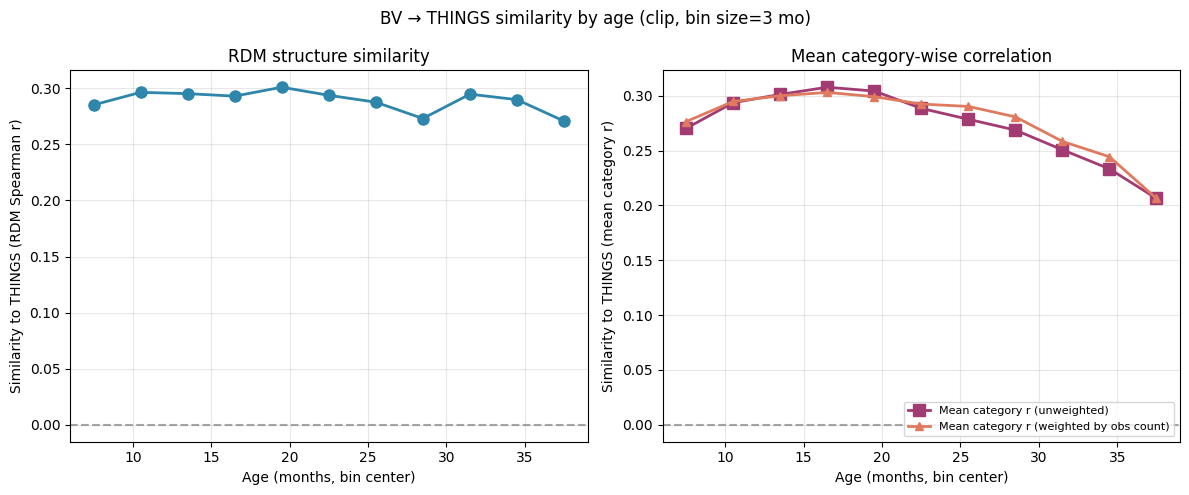

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# RDM similarity (structure)
ax = axes[0]
valid = df_results["rdm_similarity"].notna()
ax.plot(df_results.loc[valid, "age_center"], df_results.loc[valid, "rdm_similarity"], "o-", color="#2e86ab", linewidth=2, markersize=8)
ax.set_xlabel("Age (months, bin center)")
ax.set_ylabel("Similarity to THINGS (RDM Spearman r)")
ax.set_title("RDM structure similarity")
ax.grid(True, alpha=0.3)
ax.axhline(0, color="gray", linestyle="--", alpha=0.7)

# Mean category-wise correlation (first-order): unweighted and weighted by observation count
ax = axes[1]
valid = df_results["mean_category_correlation"].notna()
ax.plot(df_results.loc[valid, "age_center"], df_results.loc[valid, "mean_category_correlation"], "s-", color="#a23b72", linewidth=2, markersize=8, label="Mean category r (unweighted)")
valid_w = df_results["mean_category_correlation_weighted"].notna()
ax.plot(df_results.loc[valid_w, "age_center"], df_results.loc[valid_w, "mean_category_correlation_weighted"], "^-", color="#e07a5f", linewidth=2, markersize=6, label="Mean category r (weighted by obs count)")
ax.set_xlabel("Age (months, bin center)")
ax.set_ylabel("Similarity to THINGS (mean category r)")
ax.set_title("Mean category-wise correlation")
ax.legend(loc="lower right", fontsize=8)
ax.grid(True, alpha=0.3)
ax.axhline(0, color="gray", linestyle="--", alpha=0.7)

plt.suptitle(f"BV → THINGS similarity by age ({EMBEDDING_TYPE}, bin size={AGE_BIN_SIZE_MONTHS} mo)", fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS_OUTPUT_DIR / "bv_similarity_to_things_by_age.pdf", bbox_inches="tight")
plt.savefig(PLOTS_OUTPUT_DIR / "bv_similarity_to_things_by_age.png", dpi=150, bbox_inches="tight")
plt.show()

## Top 50 categories only: similarity to THINGS and comparison

We use the **first 50 categories from the long-tailed distribution** (same set across all subjects). We recompute BV → THINGS similarity using only those 50 categories and compare to the full (163-category) analysis. This controls for category-set heterogeneity across the developmental curve.

THINGS RDM (top 50): 50 categories
Top 50 only - first rows:


,age_min,age_max,age_center,rdm_similarity,mean_category_correlation
0,6,9,7.5,0.396735,0.284009
1,9,12,10.5,0.405201,0.298957
2,12,15,13.5,0.407159,0.302511
3,15,18,16.5,0.413943,0.303976
4,18,21,19.5,0.411601,0.301063


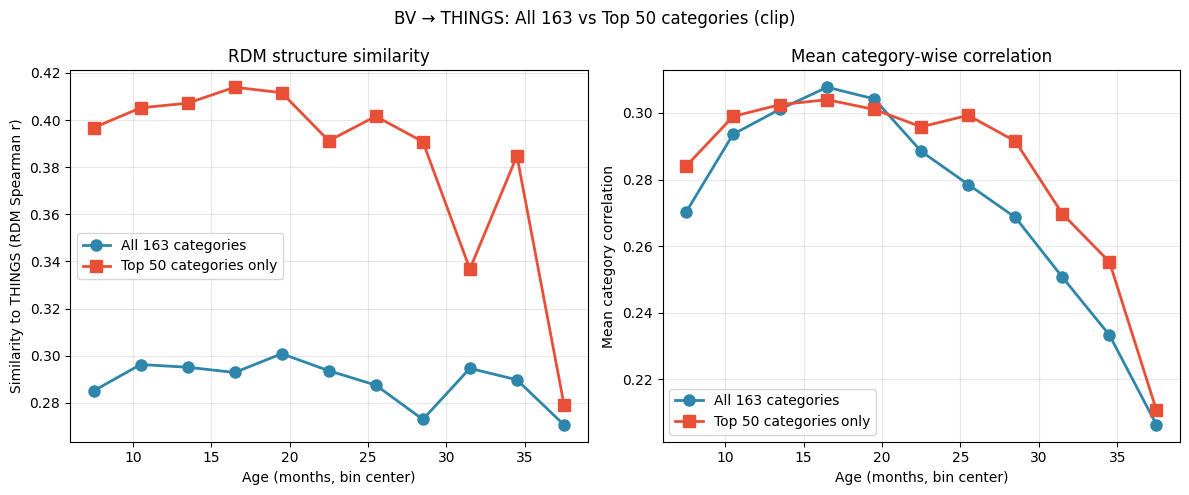

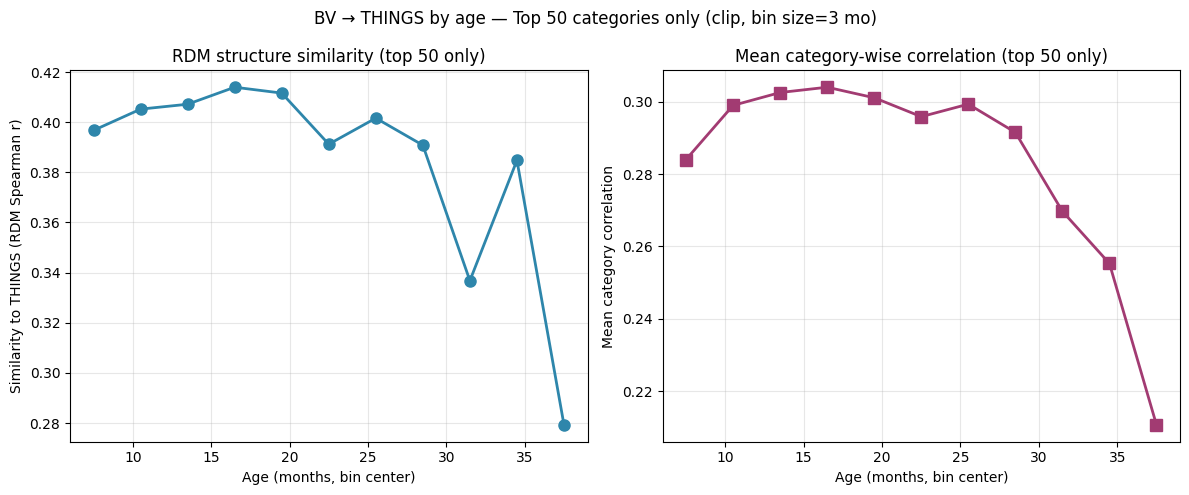

Saved: all_vs_top50 and top50_only PDF/PNG in /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/bv_similarity_to_things_plots


In [11]:
# Restrict to top 50 categories (first 50 from long-tailed distribution; same order as in CSV)
ordered_categories_top50 = [c for c in top50_cats if c in set(ordered_categories)]
things_embeddings_top50 = {c: things_embeddings[c] for c in ordered_categories_top50}
things_centroids_top50 = {c: things_embeddings_top50[c].flatten() for c in ordered_categories_top50}
things_rdm_top50, things_rdm_cats_top50 = build_rdm(
    things_centroids_top50, ordered_categories_top50, min_categories=MIN_CATEGORIES_FOR_RDM
)
if things_rdm_top50 is None:
    raise RuntimeError("THINGS RDM (top 50) could not be built.")
print(f"THINGS RDM (top 50): {len(things_rdm_cats_top50)} categories")

# Compute similarity by age bin using only top 50 categories
results_top50 = []
for (age_min, age_max) in bin_ranges:
    bv_centroids = bv_centroids_by_bin[(age_min, age_max)]
    bv_centroids_top50 = {c: bv_centroids[c] for c in top50_cats if c in bv_centroids}
    age_center = (age_min + age_max) / 2

    bv_rdm_t50, bv_rdm_cats_t50 = build_rdm(
        bv_centroids_top50, ordered_categories_top50, min_categories=MIN_CATEGORIES_FOR_RDM
    )
    rdm_corr = np.nan
    if bv_rdm_t50 is not None:
        rdm_corr = rdm_upper_triangle_correlation(
            bv_rdm_t50, things_rdm_top50, ordered_categories_top50, bv_rdm_cats_t50, things_rdm_cats_top50
        )
    mean_cat_corr = mean_category_wise_correlation(
        bv_centroids_top50, things_embeddings_top50, ordered_categories_top50
    )
    results_top50.append({
        "age_min": age_min, "age_max": age_max, "age_center": age_center,
        "rdm_similarity": rdm_corr, "mean_category_correlation": mean_cat_corr,
    })

df_results_top50 = pd.DataFrame(results_top50)
print("Top 50 only - first rows:")
display(df_results_top50.head())

# Plot 1: Comparison — All 163 vs Top 50 (same two panels as main plot)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, metric, ylabel in zip(
    axes,
    ["rdm_similarity", "mean_category_correlation"],
    ["Similarity to THINGS (RDM Spearman r)", "Mean category correlation"],
):
    v_full = df_results[metric].notna()
    v_t50 = df_results_top50[metric].notna()
    ax.plot(df_results.loc[v_full, "age_center"], df_results.loc[v_full, metric],
            "o-", color="#2e86ab", linewidth=2, markersize=8, label="All 163 categories")
    ax.plot(df_results_top50.loc[v_t50, "age_center"], df_results_top50.loc[v_t50, metric],
            "s-", color="#e94f37", linewidth=2, markersize=8, label="Top 50 categories only")
    ax.set_xlabel("Age (months, bin center)")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)
axes[0].set_title("RDM structure similarity")
axes[1].set_title("Mean category-wise correlation")
plt.suptitle(f"BV → THINGS: All 163 vs Top 50 categories ({EMBEDDING_TYPE})", fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS_OUTPUT_DIR / "bv_similarity_to_things_by_age_all_vs_top50.pdf", bbox_inches="tight")
plt.savefig(PLOTS_OUTPUT_DIR / "bv_similarity_to_things_by_age_all_vs_top50.png", dpi=150, bbox_inches="tight")
plt.show()

# Plot 2: Top 50 only (same style as main aggregate plot)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
valid = df_results_top50["rdm_similarity"].notna()
ax.plot(df_results_top50.loc[valid, "age_center"], df_results_top50.loc[valid, "rdm_similarity"],
        "o-", color="#2e86ab", linewidth=2, markersize=8)
ax.set_xlabel("Age (months, bin center)")
ax.set_ylabel("Similarity to THINGS (RDM Spearman r)")
ax.set_title("RDM structure similarity (top 50 only)")
ax.grid(True, alpha=0.3)
ax = axes[1]
valid = df_results_top50["mean_category_correlation"].notna()
ax.plot(df_results_top50.loc[valid, "age_center"], df_results_top50.loc[valid, "mean_category_correlation"],
        "s-", color="#a23b72", linewidth=2, markersize=8)
ax.set_xlabel("Age (months, bin center)")
ax.set_ylabel("Mean category correlation")
ax.set_title("Mean category-wise correlation (top 50 only)")
ax.grid(True, alpha=0.3)
plt.suptitle(f"BV → THINGS by age — Top 50 categories only ({EMBEDDING_TYPE}, bin size={AGE_BIN_SIZE_MONTHS} mo)", fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS_OUTPUT_DIR / "bv_similarity_to_things_by_age_top50_only.pdf", bbox_inches="tight")
plt.savefig(PLOTS_OUTPUT_DIR / "bv_similarity_to_things_by_age_top50_only.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: all_vs_top50 and top50_only PDF/PNG in", PLOTS_OUTPUT_DIR)

## Optional: Single plot with both metrics (same y-axis scale)

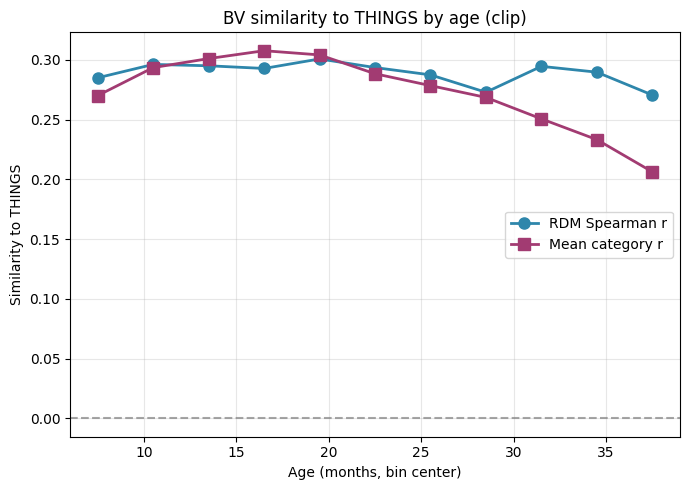

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
valid_rdm = df_results["rdm_similarity"].notna()
valid_cat = df_results["mean_category_correlation"].notna()
ax.plot(df_results.loc[valid_rdm, "age_center"], df_results.loc[valid_rdm, "rdm_similarity"], "o-", label="RDM Spearman r", color="#2e86ab", linewidth=2, markersize=8)
ax.plot(df_results.loc[valid_cat, "age_center"], df_results.loc[valid_cat, "mean_category_correlation"], "s-", label="Mean category r", color="#a23b72", linewidth=2, markersize=8)
ax.set_xlabel("Age (months, bin center)")
ax.set_ylabel("Similarity to THINGS")
ax.set_title(f"BV similarity to THINGS by age ({EMBEDDING_TYPE})")
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(0, color="gray", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## Per-subject similarity and trend lines

In addition to the aggregate trend (all subjects pooled per age bin), we compute **per-subject** similarity to THINGS in each age bin where that subject has data, then fit a **linear trend (slope)** for each subject. This lets us see whether individuals consistently increase (or decrease) in similarity with age and how much they vary.

**Why do some subjects have NaN slope?** A slope is only fitted when a subject has **at least `MIN_AGE_BINS_FOR_TREND`** (default 3) age bins with **valid** similarity. So NaN occurs when: (1) the subject has data in fewer than 3 age bins, or (2) in several bins they have too few categories (below `MIN_CATEGORIES_FOR_RDM`) to build an RDM and compute the correlation, so we get fewer than 3 valid similarity values and cannot fit a line.

In [13]:
from scipy.stats import linregress

def aggregate_bv_centroids_for_subject_in_age_bin(age_data_for_subject, age_min, age_max, allowed_categories=None):
    """For one subject, aggregate embeddings in [age_min, age_max). Returns dict category -> centroid."""
    by_cat = defaultdict(list)
    for age_mo, cats in age_data_for_subject.items():
        if not (age_min <= age_mo < age_max):
            continue
        for cat, emb in cats.items():
            if allowed_categories and cat not in allowed_categories:
                continue
            by_cat[cat].append(emb)
    return {cat: np.mean(np.stack(embs), axis=0) for cat, embs in by_cat.items() if len(embs) >= 1}

def get_per_category_embeddings_for_subject_in_age_bin(age_data_for_subject, age_min, age_max, allowed_categories=None):
    """For one subject in [age_min, age_max), return dict category -> list of embeddings (one per age_mo in bin).
    Each age_mo counts as one observation. Used for 'more data from same kid' = averaging over more observations."""
    by_cat = defaultdict(list)
    for age_mo, cats in age_data_for_subject.items():
        if not (age_min <= age_mo < age_max):
            continue
        for cat, emb in cats.items():
            if allowed_categories and cat not in allowed_categories:
                continue
            by_cat[cat].append(np.asarray(emb, dtype=np.float64).flatten())
    return {cat: embs for cat, embs in by_cat.items() if len(embs) >= 1}

def get_per_category_embeddings_with_age_for_subject_all_months(age_data_for_subject, age_lo, age_hi, allowed_categories=None):
    """For one subject, return dict category -> list of (embedding, age_mo) for all age_mo in [age_lo, age_hi).
    Used for 'same kid across all months': pool 6–39 mo (or full range) so we can sample from more density in same home."""
    by_cat = defaultdict(list)
    for age_mo, cats in age_data_for_subject.items():
        if not (age_lo <= age_mo < age_hi):
            continue
        for cat, emb in cats.items():
            if allowed_categories and cat not in allowed_categories:
                continue
            by_cat[cat].append((np.asarray(emb, dtype=np.float64).flatten(), age_mo))
    return {cat: pairs for cat, pairs in by_cat.items() if len(pairs) >= 1}

MIN_AGE_BINS_FOR_TREND = 3  # need at least this many bins with valid similarity to fit a line

per_subject_rows = []   # long format: subject_id, age_center, rdm_similarity, mean_category_correlation
subject_trends = []     # one row per subject: subject_id, slope_rdm, slope_mean_cat, intercept_rdm, intercept_mean_cat, n_bins

for subject_id, age_data in tqdm(subject_age_embeddings.items(), desc="Per-subject similarity"):
    bin_data = []  # list of (age_center, rdm_sim, mean_cat) per bin
    for (age_min, age_max) in bin_ranges:
        centroids = aggregate_bv_centroids_for_subject_in_age_bin(age_data, age_min, age_max, allowed_categories)
        if len(centroids) < MIN_CATEGORIES_FOR_RDM:
            continue
        age_center = (age_min + age_max) / 2
        bv_rdm, bv_cats = build_rdm(centroids, ordered_categories, min_categories=MIN_CATEGORIES_FOR_RDM)
        rdm_sim = np.nan
        if bv_rdm is not None:
            rdm_sim = rdm_upper_triangle_correlation(bv_rdm, things_rdm, ordered_categories, bv_cats, things_rdm_cats)
        mean_cat = mean_category_wise_correlation(centroids, things_embeddings, ordered_categories)
        per_subject_rows.append({"subject_id": subject_id, "age_center": age_center, "rdm_similarity": rdm_sim, "mean_category_correlation": mean_cat})
        bin_data.append((age_center, rdm_sim, mean_cat))
    # Fit trend for this subject if enough valid points per metric
    ages_rdm = [a for a, r, m in bin_data if not np.isnan(r)]
    vals_rdm = [r for a, r, m in bin_data if not np.isnan(r)]
    ages_cat = [a for a, r, m in bin_data if not np.isnan(m)]
    vals_cat = [m for a, r, m in bin_data if not np.isnan(m)]
    slope_rdm = intercept_rdm = slope_cat = intercept_cat = np.nan
    if len(ages_rdm) >= MIN_AGE_BINS_FOR_TREND:
        res = linregress(ages_rdm, vals_rdm)
        slope_rdm, intercept_rdm = res.slope, res.intercept
    if len(ages_cat) >= MIN_AGE_BINS_FOR_TREND:
        res = linregress(ages_cat, vals_cat)
        slope_cat, intercept_cat = res.slope, res.intercept
    subject_trends.append({
        "subject_id": subject_id,
        "slope_rdm": slope_rdm,
        "slope_mean_cat": slope_cat,
        "intercept_rdm": intercept_rdm,
        "intercept_mean_cat": intercept_cat,
        "n_age_bins": len(bin_data),
    })

df_per_subject = pd.DataFrame(per_subject_rows)
df_subject_trends = pd.DataFrame(subject_trends)
n_with_trend_rdm = df_subject_trends["slope_rdm"].notna().sum()
n_with_trend_cat = df_subject_trends["slope_mean_cat"].notna().sum()
print(f"Per-subject trajectories: {len(df_per_subject)} subject-bin points from {df_per_subject['subject_id'].nunique()} subjects")
print(f"Subjects with fitted RDM trend (≥{MIN_AGE_BINS_FOR_TREND} bins): {n_with_trend_rdm}; mean category: {n_with_trend_cat}")
n_nan_rdm = df_subject_trends["slope_rdm"].isna().sum()
if n_nan_rdm > 0:
    print(f"\nWhy NaN slope_rdm? Subjects with NaN have fewer than {MIN_AGE_BINS_FOR_TREND} age bins with valid similarity. "
          f"That happens when a subject has data in few bins, or in some bins has <{MIN_CATEGORIES_FOR_RDM} categories (so we skip that bin).")
df_subject_trends

Per-subject similarity: 100%|██████████| 31/31 [00:02<00:00, 10.58it/s]

Per-subject trajectories: 114 subject-bin points from 31 subjects
Subjects with fitted RDM trend (≥3 bins): 21; mean category: 21

Why NaN slope_rdm? Subjects with NaN have fewer than 3 age bins with valid similarity. That happens when a subject has data in few bins, or in some bins has <8 categories (so we skip that bin).


,subject_id,slope_rdm,slope_mean_cat,intercept_rdm,intercept_mean_cat,n_age_bins
0,00320001,0.005342,-0.004457,0.215293,0.306817,5
1,00680001,NaN,NaN,NaN,NaN,2
2,00320002,-0.008356,-0.001145,0.386622,0.250096,5
3,00500001,0.000316,-0.000762,0.287062,0.257974,6
4,00400001,0.003167,-0.000052,0.216288,0.250632,7
5,00430001,-0.003130,-0.000304,0.341432,0.231716,6
6,00820001,-0.000490,-0.000964,0.297215,0.266065,7
7,00220001,-0.012195,-0.003055,0.456559,0.253919,4
8,00560001,-0.001624,-0.004296,0.304454,0.320019,6
9,00370001,-0.003533,-0.002698,0.332101,0.284942,4


## Similarity beyond 30 months and flagged subjects

**Where do aggregate similarity values beyond 30 months come from?** We do not have subject-wise *trajectories* beyond 30 months (each subject only has data in a limited age range). The **aggregate** curve, however, pools all subjects per age bin: for bins with age_center > 30 months, the similarity is computed from whichever subjects happen to have data in that bin. Those subjects may have only one or two age bins with valid similarity (e.g. few categories), so they do **not** get a per-subject trend (slope) — we require at least 3 bins to fit a line. So: **aggregate similarity at older ages can come largely from subjects who contribute to those bins but do not have enough data for a trajectory (we flag them as "no trajectory").** Below we flag those subjects per bin and list the overlapping categories used for BV vs THINGS similarity.

In [14]:
# Flag subjects who have no trajectory (NaN slope) and report their contribution per bin
subject_ids_no_trajectory = set(df_subject_trends.loc[df_subject_trends["slope_rdm"].isna(), "subject_id"])
df_results["subjects_no_trajectory"] = [
    list(set(row["contributing_subject_ids"]) & subject_ids_no_trajectory)
    for _, row in df_results.iterrows()
]
df_results["n_no_trajectory"] = df_results["subjects_no_trajectory"].apply(len)

# Summary: bins with age > 30 months and/or contributors without trajectory
display_cols = ["age_min", "age_max", "age_center", "n_contributing", "n_no_trajectory", "n_shared_categories"]
summary = df_results[display_cols].copy()
summary["subjects_no_trajectory"] = df_results["subjects_no_trajectory"].apply(
    lambda x: ", ".join(x) if x else ""
)
print("Per-bin summary (contributors and subjects without trajectory):")
display(summary)

# Overlapping categories used for BV vs THINGS similarity (same for RDM and mean-category when both use same subset)
# Save full lists per bin to a file and show first bin as example
overlap_out = PLOTS_OUTPUT_DIR / "overlapping_categories_by_bin.txt"
with open(overlap_out, "w") as f:
    f.write("Age bin (min-max)\tage_center\tn_shared\tOverlapping categories (mean_cat; RDM uses same when >= MIN_CATEGORIES_FOR_RDM)\n")
    for _, row in df_results.iterrows():
        cats_mean = row["overlapping_categories_mean_cat"]
        cats_rdm = row["overlapping_categories_rdm"]
        n_shared = len(cats_mean)
        f.write(f"{row['age_min']}-{row['age_max']}\t{row['age_center']}\t{n_shared}\t{', '.join(cats_mean)}\n")
print(f"\nOverlapping categories (mean_cat) per bin written to: {overlap_out}")

# Show first few bins' overlapping categories in the notebook
print("\nOverlapping categories (first 3 age bins, mean_cat):")
for _, row in df_results.head(3).iterrows():
    cats = row["overlapping_categories_mean_cat"]
    n = len(cats)
    preview = ", ".join(cats[:15]) + (f" ... and {n - 15} more" if n > 15 else "")
    print(f"  {row['age_min']}-{row['age_max']} mo (n={n}): {preview}")

Per-bin summary (contributors and subjects without trajectory):


,age_min,age_max,age_center,n_contributing,n_no_trajectory,n_shared_categories,subjects_no_trajectory
0,6,9,7.5,5,0,142,
1,9,12,10.5,19,7,160,"00430002, 00350001, 00390001, 00350002, 003600..."
2,12,15,13.5,23,4,160,"00440001, 00390001, 00360001, 00460001"
3,15,18,16.5,22,3,162,"00440001, 00680001, 00550001"
4,18,21,19.5,20,1,160,00680001
5,21,24,22.5,10,0,155,
6,24,27,25.5,6,0,151,
7,27,30,28.5,6,0,140,
8,30,33,31.5,1,0,133,
9,33,36,34.5,1,0,115,



Overlapping categories (mean_cat) per bin written to: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/bv_similarity_to_things_plots/overlapping_categories_by_bin.txt

Overlapping categories (first 3 age bins, mean_cat):
  6-9 mo (n=142): ankle, apple, applesauce, arm, ball, balloon, banana, basket, bathtub, bed, belt, bench, bib, bird, blanket ... and 127 more
  9-12 mo (n=160): alligator, ankle, apple, applesauce, arm, ball, balloon, banana, basket, bathtub, bear, bed, belt, bench, bib ... and 145 more
  12-15 mo (n=160): alligator, ankle, apple, applesauce, arm, ball, balloon, banana, basket, bathtub, bear, bed, belt, bench, bib ... and 145 more


## Restricting to subjects with enough data (recommended)

Because each subject has different numbers of overlapping categories with THINGS and different age coverage, **restricting to subjects with enough data** (those with a fitted trajectory: ≥ `MIN_AGE_BINS_FOR_TREND` age bins with valid similarity) makes aggregate and n-subjects analyses more comparable. When `USE_ONLY_SUBJECTS_WITH_TRAJECTORY` is True we compute a **filtered** aggregate (`df_results_filtered`) and use only these subjects for the **similarity vs number of subjects** plot below.

## Similarity vs number of subjects (within age bin)

Here we ask: **as we add more kids (pool more subjects) within each age bin, does similarity to THINGS go up or down?** X-axis = number of subjects pooled (1, 2, …, N in that bin), Y-axis = similarity to THINGS. For each k we repeatedly sample k subjects at random, pool their embeddings in that bin, compute RDM and mean-category similarity, and average over samples. One line per age bin. Data heterogeneity remains (different k can have different overlapping category sets); we use the same metrics on the union of categories available for the sampled subjects.

In [15]:
# Optional: restrict to subjects with enough data (fitted trajectory)
subject_ids_with_trajectory = set(df_subject_trends.loc[df_subject_trends["slope_rdm"].notna(), "subject_id"])
filtered_bv_centroids_by_bin = {}
filtered_contributing_by_bin = {}
df_results_filtered = None

if USE_ONLY_SUBJECTS_WITH_TRAJECTORY and len(subject_ids_with_trajectory) > 0:
    filtered_embeddings = {sid: subject_age_embeddings[sid] for sid in subject_ids_with_trajectory if sid in subject_age_embeddings}
    for age_min, age_max in bin_ranges:
        centroids, contributors, _ = aggregate_bv_centroids_for_age_bin(
            filtered_embeddings, age_min, age_max, allowed_categories
        )
        filtered_bv_centroids_by_bin[(age_min, age_max)] = centroids
        filtered_contributing_by_bin[(age_min, age_max)] = contributors

    results_filtered = []
    for (age_min, age_max) in bin_ranges:
        bv_centroids = filtered_bv_centroids_by_bin[(age_min, age_max)]
        contributing_subject_ids = filtered_contributing_by_bin[(age_min, age_max)]
        age_center = (age_min + age_max) / 2
        bv_rdm, bv_rdm_cats = build_rdm(bv_centroids, ordered_categories, min_categories=MIN_CATEGORIES_FOR_RDM)
        rdm_corr = np.nan
        overlapping_categories_rdm = []
        if bv_rdm is not None:
            overlapping_categories_rdm = [c for c in ordered_categories if c in bv_rdm_cats and c in things_rdm_cats]
            rdm_corr = rdm_upper_triangle_correlation(bv_rdm, things_rdm, ordered_categories, bv_rdm_cats, things_rdm_cats)
        mean_cat_corr = mean_category_wise_correlation(bv_centroids, things_embeddings, ordered_categories)
        overlapping_categories_mean_cat = [c for c in ordered_categories if c in bv_centroids and c in things_embeddings]
        n_shared = len(overlapping_categories_mean_cat)
        results_filtered.append({
            "age_min": age_min, "age_max": age_max, "age_center": age_center,
            "rdm_similarity": rdm_corr, "mean_category_correlation": mean_cat_corr,
            "n_categories_bv": len(bv_centroids), "n_shared_categories": n_shared,
            "contributing_subject_ids": list(contributing_subject_ids), "n_contributing": len(contributing_subject_ids),
            "overlapping_categories_rdm": overlapping_categories_rdm, "overlapping_categories_mean_cat": overlapping_categories_mean_cat,
        })
    df_results_filtered = pd.DataFrame(results_filtered)
    print(f"Filtered to {len(subject_ids_with_trajectory)} subjects with trajectory. df_results_filtered:")
    display(df_results_filtered[["age_min", "age_max", "age_center", "rdm_similarity", "mean_category_correlation", "n_contributing"]])
else:
    # Use full contributor sets for n-subjects plot
    filtered_bv_centroids_by_bin = bv_centroids_by_bin
    filtered_contributing_by_bin = contributing_subjects_by_bin
    filtered_embeddings = subject_age_embeddings
    print("Using all subjects (USE_ONLY_SUBJECTS_WITH_TRAJECTORY is False or no subjects with trajectory).")

# For n-subjects analysis: pool from this embedding dict (filtered or full)
embeddings_for_n_subjects = filtered_embeddings if (USE_ONLY_SUBJECTS_WITH_TRAJECTORY and len(subject_ids_with_trajectory) > 0) else subject_age_embeddings

Filtered to 21 subjects with trajectory. df_results_filtered:


,age_min,age_max,age_center,rdm_similarity,mean_category_correlation,n_contributing
0,6,9,7.5,0.285066,0.270195,5
1,9,12,10.5,0.289329,0.293054,12
2,12,15,13.5,0.295199,0.300891,19
3,15,18,16.5,0.293423,0.305989,19
4,18,21,19.5,0.297719,0.301468,19
5,21,24,22.5,0.293638,0.288457,10
6,24,27,25.5,0.287511,0.278515,6
7,27,30,28.5,0.272961,0.268646,6
8,30,33,31.5,0.294646,0.250694,1
9,33,36,34.5,0.289766,0.233316,1


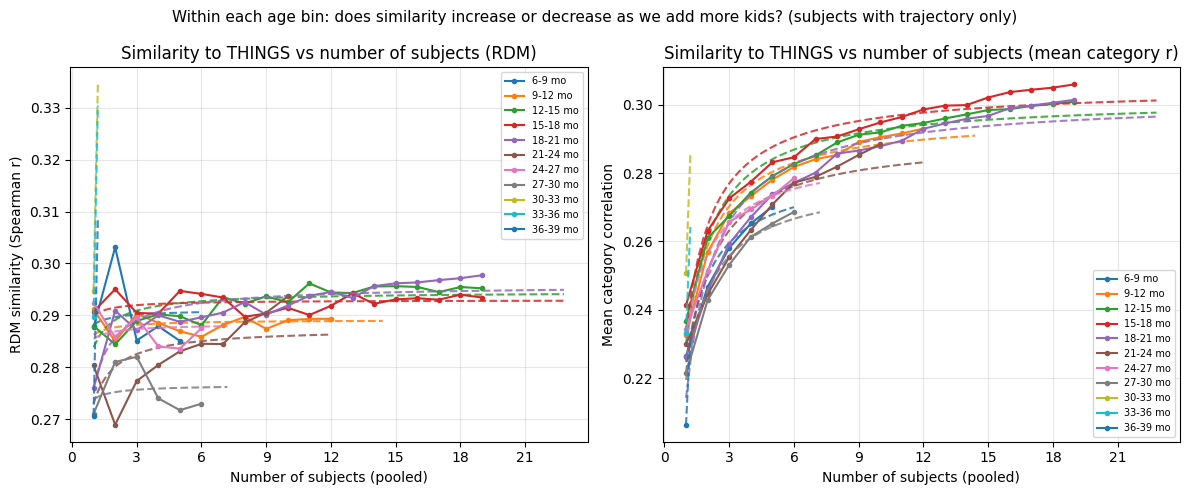

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/bv_similarity_to_things_plots/bv_similarity_to_things_vs_n_subjects.png
Estimated upper asymptote L (saturation model L*n/(k+n)); dashed curves = fit. Adding more participants is unlikely to raise similarity much above L.


,age_bin,L_rdm,k_rdm,L_cat,k_cat,n_max
0,6-9 mo,0.291086,0.010000,0.281385,0.252216,5
1,9-12 mo,0.289116,0.010000,0.296944,0.295433,12
2,12-15 mo,0.294557,0.037743,0.301771,0.311503,19
3,15-18 mo,0.292929,0.010000,0.305321,0.306597,19
4,18-21 mo,0.295822,0.070662,0.301855,0.409177,19
5,21-24 mo,0.287560,0.053507,0.290497,0.311227,10
6,24-27 mo,0.288300,0.010000,0.286124,0.233394,6
7,27-30 mo,0.276566,0.010000,0.278594,0.269390,6
8,30-33 mo,1.033600,2.507944,0.929138,2.706260,1
9,33-36 mo,1.107711,2.822784,0.784076,2.360569,1


In [16]:
import random
from matplotlib.ticker import MaxNLocator
from scipy.optimize import curve_fit

# Saturating model: similarity -> L as n -> infinity.  y = L * n / (k + n)
def _saturating(n, L, k):
    return L * n / (k + n)

# Similarity vs number of subjects (within each age bin)
# For each bin: for k = 1, 2, ..., N (contributors), sample k subjects, pool, compute similarity, average over samples
n_subjects_curves = []  # list of dicts: bin_key, k, mean_rdm, mean_cat, sem_rdm, sem_cat

for (age_min, age_max) in bin_ranges:
    contributors = list(filtered_contributing_by_bin[(age_min, age_max)])
    N = len(contributors)
    if N < 1:
        continue
    for k in range(1, N + 1):
        rdm_vals, cat_vals = [], []
        for _ in range(N_SAMPLES_FOR_N_SUBJECTS):
            if k > N:
                break
            chosen = random.sample(contributors, k)
            sub_emb = {sid: embeddings_for_n_subjects[sid] for sid in chosen if sid in embeddings_for_n_subjects}
            centroids, _, _ = aggregate_bv_centroids_for_age_bin(sub_emb, age_min, age_max, allowed_categories)
            bv_rdm, bv_cats = build_rdm(centroids, ordered_categories, min_categories=MIN_CATEGORIES_FOR_RDM)
            r_sim = np.nan
            if bv_rdm is not None:
                r_sim = rdm_upper_triangle_correlation(bv_rdm, things_rdm, ordered_categories, bv_cats, things_rdm_cats)
            c_sim = mean_category_wise_correlation(centroids, things_embeddings, ordered_categories)
            if np.isfinite(r_sim):
                rdm_vals.append(r_sim)
            if np.isfinite(c_sim):
                cat_vals.append(c_sim)
        mean_rdm = np.nanmean(rdm_vals) if rdm_vals else np.nan
        mean_cat = np.nanmean(cat_vals) if cat_vals else np.nan
        sem_rdm = np.nanstd(rdm_vals, ddof=1) / np.sqrt(len(rdm_vals)) if len(rdm_vals) > 1 else np.nan
        sem_cat = np.nanstd(cat_vals, ddof=1) / np.sqrt(len(cat_vals)) if len(cat_vals) > 1 else np.nan
        n_subjects_curves.append({
            "age_min": age_min, "age_max": age_max, "age_center": (age_min + age_max) / 2,
            "k": k, "mean_rdm": mean_rdm, "mean_cat": mean_cat, "sem_rdm": sem_rdm, "sem_cat": sem_cat,
        })

df_n_subjects = pd.DataFrame(n_subjects_curves)

# Fit saturating curve (L * n / (k + n)) per age bin to estimate upper asymptote L
asymptote_results = []
for (age_min, age_max), grp in df_n_subjects.groupby(["age_min", "age_max"]):
    k_vals = grp["k"].values.astype(float)
    L_rdm, k_rdm = np.nan, np.nan
    L_cat, k_cat = np.nan, np.nan
    try:
        popt_rdm, _ = curve_fit(
            _saturating, k_vals, grp["mean_rdm"].values,
            p0=[grp["mean_rdm"].max(), 5.0], bounds=([0.01, 0.01], [1.5, 500]))
        L_rdm, k_rdm = popt_rdm[0], popt_rdm[1]
    except Exception:
        pass
    try:
        popt_cat, _ = curve_fit(
            _saturating, k_vals, grp["mean_cat"].values,
            p0=[grp["mean_cat"].max(), 5.0], bounds=([0.01, 0.01], [1.5, 500]))
        L_cat, k_cat = popt_cat[0], popt_cat[1]
    except Exception:
        pass
    asymptote_results.append({
        "age_bin": f"{age_min}-{age_max} mo", "age_min": age_min, "age_max": age_max,
        "L_rdm": L_rdm, "k_rdm": k_rdm, "L_cat": L_cat, "k_cat": k_cat, "n_max": len(grp),
    })
df_asymptotes = pd.DataFrame(asymptote_results)

# Plot: two panels (RDM, mean category), one line per age bin + fitted saturation curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for (age_min, age_max), grp in df_n_subjects.groupby(["age_min", "age_max"]):
    label = f"{age_min}-{age_max} mo"
    axes[0].plot(grp["k"], grp["mean_rdm"], "o-", label=label, markersize=3)
    axes[1].plot(grp["k"], grp["mean_cat"], "o-", label=label, markersize=3)
    # Overlay fitted saturation curve (upper asymptote L)
    row = df_asymptotes[(df_asymptotes["age_min"] == age_min) & (df_asymptotes["age_max"] == age_max)].iloc[0]
    n_smooth = np.linspace(1, grp["k"].max() * 1.2, 80)
    if np.isfinite(row["L_rdm"]):
        axes[0].plot(n_smooth, _saturating(n_smooth, row["L_rdm"], row["k_rdm"]), "--", color=axes[0].get_lines()[-1].get_color(), alpha=0.85, lw=1.5)
    if np.isfinite(row["L_cat"]):
        axes[1].plot(n_smooth, _saturating(n_smooth, row["L_cat"], row["k_cat"]), "--", color=axes[1].get_lines()[-1].get_color(), alpha=0.85, lw=1.5)
axes[0].set_xlabel("Number of subjects (pooled)")
axes[0].set_ylabel("RDM similarity (Spearman r)")
axes[0].set_title("Similarity to THINGS vs number of subjects (RDM)")
axes[0].legend(loc="best", fontsize=7)
axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel("Number of subjects (pooled)")
axes[1].set_ylabel("Mean category correlation")
axes[1].set_title("Similarity to THINGS vs number of subjects (mean category r)")
axes[1].legend(loc="best", fontsize=7)
axes[1].grid(True, alpha=0.3)
for ax in axes:
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
title_suffix = " (subjects with trajectory only)" if USE_ONLY_SUBJECTS_WITH_TRAJECTORY and len(subject_ids_with_trajectory) > 0 else " (all subjects)"
plt.suptitle("Within each age bin: does similarity increase or decrease as we add more kids?" + title_suffix, fontsize=11)
plt.tight_layout()
out_path = PLOTS_OUTPUT_DIR / "bv_similarity_to_things_vs_n_subjects.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")
print("Estimated upper asymptote L (saturation model L*n/(k+n)); dashed curves = fit. Adding more participants is unlikely to raise similarity much above L.")
display(df_asymptotes[["age_bin", "L_rdm", "k_rdm", "L_cat", "k_cat", "n_max"]])

## More data from same kid vs more kids

We compare two ways to increase the amount of data: **(1) more kids** (pool more subjects in the same age bin — current plot) vs **(2) more data from the same kid** (average over more **observations (age months)** per category: we don't have video-level embeddings, so each subject's embedding per (age_mo, category) counts as one observation; within an age bin a subject can have multiple age_mo values, so multiple observations per category. We subsample 1, 2, …, k of those and average to form centroids, then compute similarity). If both curves asymptote at a similar level, it suggests the plateau reflects a ceiling on how close BV gets to THINGS, not just limited sample size.

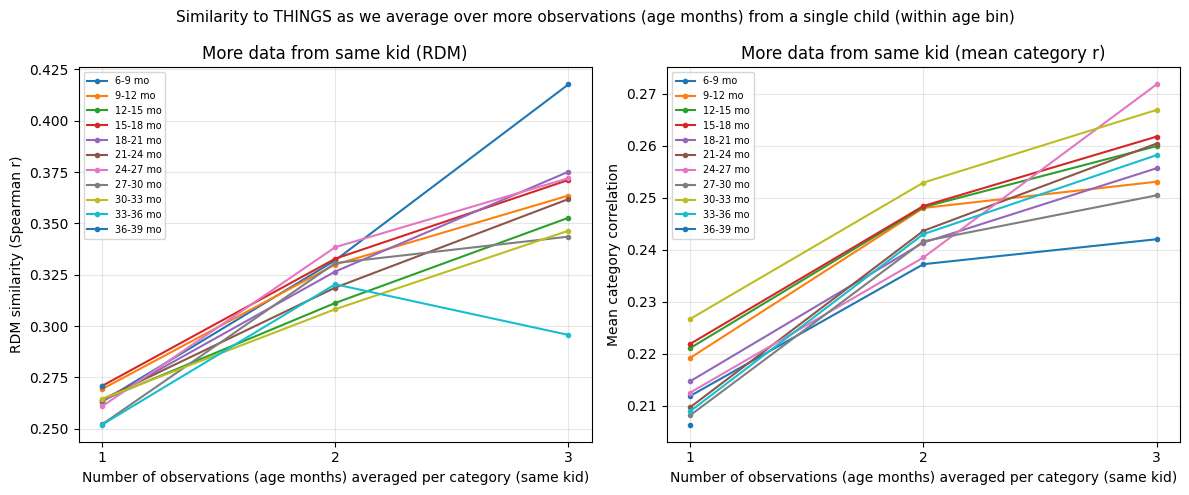

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/bv_similarity_to_things_plots/bv_similarity_to_things_same_kid_more_observations.png


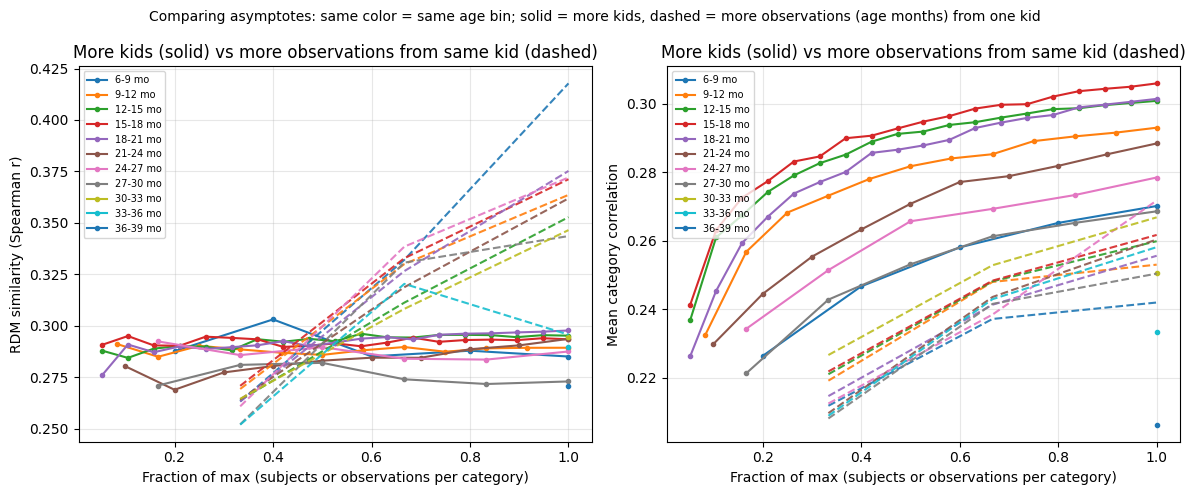

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/bv_similarity_to_things_plots/bv_similarity_to_things_more_kids_vs_same_kid_normalized.png


In [17]:
# More data from same kid: within each age bin, for each subject average over k observations (age_mo) per category
# We don't have video-level embeddings; each (age_mo, category) = one observation. Subsample k, average to centroid.
K_MAX_OBS_SAMEKID = 15  # cap for x-axis (number of observations = age months averaged per category)
N_SAMPLES_SAMEKID = 25  # random subsamples per (subject, k)

samekid_curves = []
for (age_min, age_max) in bin_ranges:
    contributors = list(filtered_contributing_by_bin[(age_min, age_max)])
    if len(contributors) == 0:
        continue
    # Per subject: dict category -> list of embeddings (one per age_mo in this bin = one observation each)
    subject_obs = {}
    for sid in contributors:
        if sid not in embeddings_for_n_subjects:
            continue
        obs = get_per_category_embeddings_for_subject_in_age_bin(
            embeddings_for_n_subjects[sid], age_min, age_max, allowed_categories
        )
        if len(obs) >= MIN_CATEGORIES_FOR_RDM:
            subject_obs[sid] = obs
    if not subject_obs:
        continue
    # k = number of observations (age months) to average per category (1, 2, ..., up to max available)
    max_obs = max(len(embs) for obs in subject_obs.values() for embs in obs.values())
    k_range = range(1, min(K_MAX_OBS_SAMEKID, max_obs) + 1)
    for k in k_range:
        rdm_vals, cat_vals = [], []
        for sid, cat_to_embs in subject_obs.items():
            # Only categories with at least k observations
            cats_ok = [c for c, embs in cat_to_embs.items() if len(embs) >= k]
            if len(cats_ok) < MIN_CATEGORIES_FOR_RDM:
                continue
            for _ in range(N_SAMPLES_SAMEKID):
                centroids_k = {}
                for cat in cats_ok:
                    embs = cat_to_embs[cat]
                    idx = random.sample(range(len(embs)), k) if len(embs) >= k else range(len(embs))
                    chosen = [embs[i] for i in idx]
                    centroids_k[cat] = np.mean(np.stack(chosen), axis=0)
                bv_rdm, bv_cats = build_rdm(centroids_k, ordered_categories, min_categories=MIN_CATEGORIES_FOR_RDM)
                r_sim = np.nan
                if bv_rdm is not None:
                    r_sim = rdm_upper_triangle_correlation(bv_rdm, things_rdm, ordered_categories, bv_cats, things_rdm_cats)
                c_sim = mean_category_wise_correlation(centroids_k, things_embeddings, ordered_categories)
                if np.isfinite(r_sim):
                    rdm_vals.append(r_sim)
                if np.isfinite(c_sim):
                    cat_vals.append(c_sim)
        if not rdm_vals and not cat_vals:
            continue
        samekid_curves.append({
            "age_min": age_min, "age_max": age_max, "age_center": (age_min + age_max) / 2,
            "k_obs": k, "mean_rdm": np.nanmean(rdm_vals) if rdm_vals else np.nan,
            "mean_cat": np.nanmean(cat_vals) if cat_vals else np.nan,
        })
df_samekid = pd.DataFrame(samekid_curves)

# Plot 1: More data from same kid (more observations = age months averaged per category)
fig1, ax1 = plt.subplots(1, 2, figsize=(12, 5))
for (age_min, age_max), grp in df_samekid.groupby(["age_min", "age_max"]):
    label = f"{age_min}-{age_max} mo"
    ax1[0].plot(grp["k_obs"], grp["mean_rdm"], "o-", label=label, markersize=3)
    ax1[1].plot(grp["k_obs"], grp["mean_cat"], "o-", label=label, markersize=3)
ax1[0].set_xlabel("Number of observations (age months) averaged per category (same kid)")
ax1[0].set_ylabel("RDM similarity (Spearman r)")
ax1[0].set_title("More data from same kid (RDM)")
ax1[0].legend(loc="best", fontsize=7)
ax1[0].grid(True, alpha=0.3)
ax1[0].xaxis.set_major_locator(MaxNLocator(integer=True))
ax1[1].set_xlabel("Number of observations (age months) averaged per category (same kid)")
ax1[1].set_ylabel("Mean category correlation")
ax1[1].set_title("More data from same kid (mean category r)")
ax1[1].legend(loc="best", fontsize=7)
ax1[1].grid(True, alpha=0.3)
ax1[1].xaxis.set_major_locator(MaxNLocator(integer=True))
plt.suptitle("Similarity to THINGS as we average over more observations (age months) from a single child (within age bin)", fontsize=11)
plt.tight_layout()
plt.savefig(PLOTS_OUTPUT_DIR / "bv_similarity_to_things_same_kid_more_observations.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOTS_OUTPUT_DIR / 'bv_similarity_to_things_same_kid_more_observations.png'}")

# Plot 2: Overlay more kids vs same kid with normalized x to compare asymptotes (same color = same age bin)
fig2, ax2 = plt.subplots(1, 2, figsize=(12, 5))
colors = plt.cm.tab10(np.linspace(0, 1, 10))
for idx, ((age_min, age_max), grp) in enumerate(df_n_subjects.groupby(["age_min", "age_max"])):
    label = f"{age_min}-{age_max} mo"
    c = colors[idx % len(colors)]
    n_max = grp["k"].max()
    x_norm = grp["k"].values / n_max
    ax2[0].plot(x_norm, grp["mean_rdm"].values, "o-", color=c, label=label, markersize=3)
    ax2[1].plot(x_norm, grp["mean_cat"].values, "o-", color=c, label=label, markersize=3)
for idx, ((age_min, age_max), grp) in enumerate(df_samekid.groupby(["age_min", "age_max"])):
    c = colors[idx % len(colors)]
    k_max = grp["k_obs"].max()
    x_norm = grp["k_obs"].values / k_max
    ax2[0].plot(x_norm, grp["mean_rdm"].values, "--", color=c, alpha=0.9)
    ax2[1].plot(x_norm, grp["mean_cat"].values, "--", color=c, alpha=0.9)
ax2[0].set_xlabel("Fraction of max (subjects or observations per category)")
ax2[0].set_ylabel("RDM similarity (Spearman r)")
ax2[0].set_title("More kids (solid) vs more observations from same kid (dashed)")
ax2[0].legend(loc="best", fontsize=7)
ax2[0].grid(True, alpha=0.3)
ax2[1].set_xlabel("Fraction of max (subjects or observations per category)")
ax2[1].set_ylabel("Mean category correlation")
ax2[1].set_title("More kids (solid) vs more observations from same kid (dashed)")
ax2[1].legend(loc="best", fontsize=7)
ax2[1].grid(True, alpha=0.3)
plt.suptitle("Comparing asymptotes: same color = same age bin; solid = more kids, dashed = more observations (age months) from one kid", fontsize=10)
plt.tight_layout()
plt.savefig(PLOTS_OUTPUT_DIR / "bv_similarity_to_things_more_kids_vs_same_kid_normalized.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOTS_OUTPUT_DIR / 'bv_similarity_to_things_more_kids_vs_same_kid_normalized.png'}")

## Same kid, aggregated across all months (6–39 mo)

Instead of stratifying by age bin, we pool **all** of each subject's data across the full age range (e.g. 6–39 months). For each subject we have multiple observations (age months) per category; we subsample k of them and average to form centroids, then compute similarity. **One curve** (not colored by age bin) to see if more density from the same home does the same thing as more homes. We track the **mean age (months) of the sampled observations** at each k and show it in a second panel so you can see which months are being averaged.

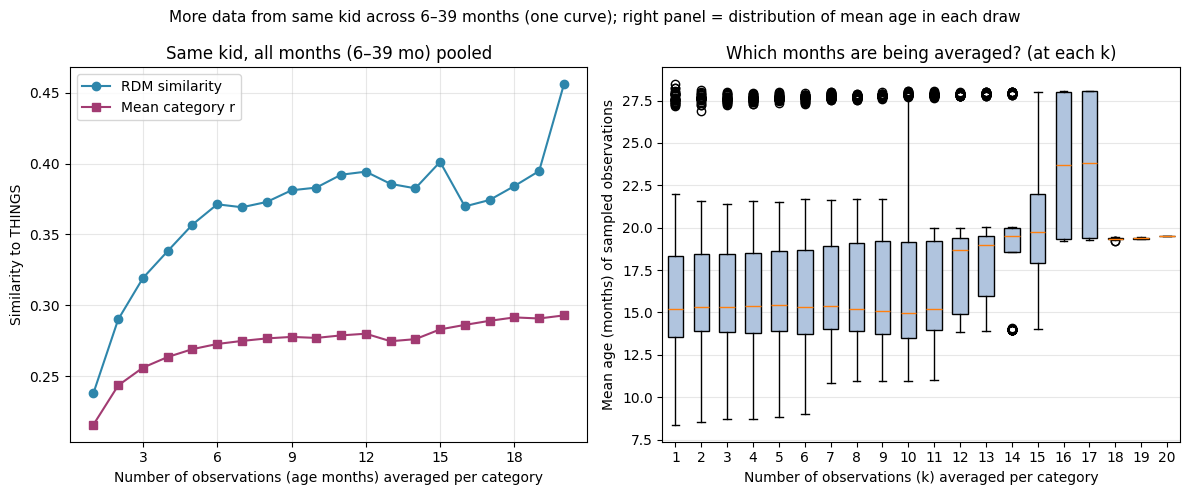

Saved: /home/j7yang/babyview-projects/vss2026/object-detection/analysis/individual_analyses/bv_similarity_to_things_plots/bv_similarity_to_things_same_kid_all_months.png


In [18]:
# Same kid across ALL months (6–39): one curve, no age-bin coloring. Track mean age of sampled obs.
AGE_LO_ALLMONTHS = 6
AGE_HI_ALLMONTHS = 40   # exclusive, so 6–39 mo
K_MAX_OBS_ALLMONTHS = 25
N_SAMPLES_ALLMONTHS = 30

# Use same embedding set as other same-kid analysis
embeddings_source = embeddings_for_n_subjects if (USE_ONLY_SUBJECTS_WITH_TRAJECTORY and len(subject_ids_with_trajectory) > 0) else subject_age_embeddings

samekid_allmonths_rows = []   # each row = one (subject, sample): k_obs, mean_rdm, mean_cat, mean_age_sampled
for sid, age_data in embeddings_source.items():
    cat_to_pairs = get_per_category_embeddings_with_age_for_subject_all_months(
        age_data, AGE_LO_ALLMONTHS, AGE_HI_ALLMONTHS, allowed_categories
    )
    if len(cat_to_pairs) < MIN_CATEGORIES_FOR_RDM:
        continue
    max_obs = max(len(pairs) for pairs in cat_to_pairs.values())
    k_range = range(1, min(K_MAX_OBS_ALLMONTHS, max_obs) + 1)
    for k in k_range:
        cats_ok = [c for c, pairs in cat_to_pairs.items() if len(pairs) >= k]
        if len(cats_ok) < MIN_CATEGORIES_FOR_RDM:
            continue
        for _ in range(N_SAMPLES_ALLMONTHS):
            centroids_k = {}
            ages_sampled = []
            for cat in cats_ok:
                pairs = cat_to_pairs[cat]
                idx = random.sample(range(len(pairs)), k)
                chosen = [pairs[i] for i in idx]
                embs = np.stack([p[0] for p in chosen])
                centroids_k[cat] = np.mean(embs, axis=0)
                ages_sampled.extend([p[1] for p in chosen])
            mean_age_sampled = np.mean(ages_sampled)
            bv_rdm, bv_cats = build_rdm(centroids_k, ordered_categories, min_categories=MIN_CATEGORIES_FOR_RDM)
            r_sim = np.nan
            if bv_rdm is not None:
                r_sim = rdm_upper_triangle_correlation(bv_rdm, things_rdm, ordered_categories, bv_cats, things_rdm_cats)
            c_sim = mean_category_wise_correlation(centroids_k, things_embeddings, ordered_categories)
            samekid_allmonths_rows.append({
                "k_obs": k, "mean_rdm": r_sim, "mean_cat": c_sim, "mean_age_sampled": mean_age_sampled,
            })

df_samekid_allmonths = pd.DataFrame(samekid_allmonths_rows)
# Aggregate for main curve: mean similarity per k
df_curve = df_samekid_allmonths.groupby("k_obs").agg(
    mean_rdm=("mean_rdm", lambda x: np.nanmean(x[np.isfinite(x)]) if np.any(np.isfinite(x)) else np.nan),
    mean_cat=("mean_cat", lambda x: np.nanmean(x[np.isfinite(x)]) if np.any(np.isfinite(x)) else np.nan),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Left: similarity vs k (one curve, all months pooled)
ax = axes[0]
ax.plot(df_curve["k_obs"], df_curve["mean_rdm"], "o-", color="#2e86ab", label="RDM similarity", markersize=6)
ax.plot(df_curve["k_obs"], df_curve["mean_cat"], "s-", color="#a23b72", label="Mean category r", markersize=6)
ax.set_xlabel("Number of observations (age months) averaged per category")
ax.set_ylabel("Similarity to THINGS")
ax.set_title("Same kid, all months (6–39 mo) pooled")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# Right: at each k, distribution of mean age (months) of the sampled observations
ax = axes[1]
df_samekid_allmonths_finite = df_samekid_allmonths.dropna(subset=["mean_age_sampled"])
if len(df_samekid_allmonths_finite) > 0:
    k_vals = sorted(df_samekid_allmonths_finite["k_obs"].unique())
    positions = []
    data_for_box = []
    for i, k in enumerate(k_vals):
        subset = df_samekid_allmonths_finite[df_samekid_allmonths_finite["k_obs"] == k]["mean_age_sampled"]
        if len(subset) > 0:
            positions.append(k)
            data_for_box.append(subset.values)
    if data_for_box:
        bp = ax.boxplot(data_for_box, positions=positions, widths=0.6, patch_artist=True)
        for patch in bp["boxes"]:
            patch.set_facecolor("lightsteelblue")
        ax.set_xticks(positions)
        ax.set_xticklabels(positions)
ax.set_xlabel("Number of observations (k) averaged per category")
ax.set_ylabel("Mean age (months) of sampled observations")
ax.set_title("Which months are being averaged? (at each k)")
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("More data from same kid across 6–39 months (one curve); right panel = distribution of mean age in each draw", fontsize=11)
plt.tight_layout()
plt.savefig(PLOTS_OUTPUT_DIR / "bv_similarity_to_things_same_kid_all_months.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PLOTS_OUTPUT_DIR / 'bv_similarity_to_things_same_kid_all_months.png'}")

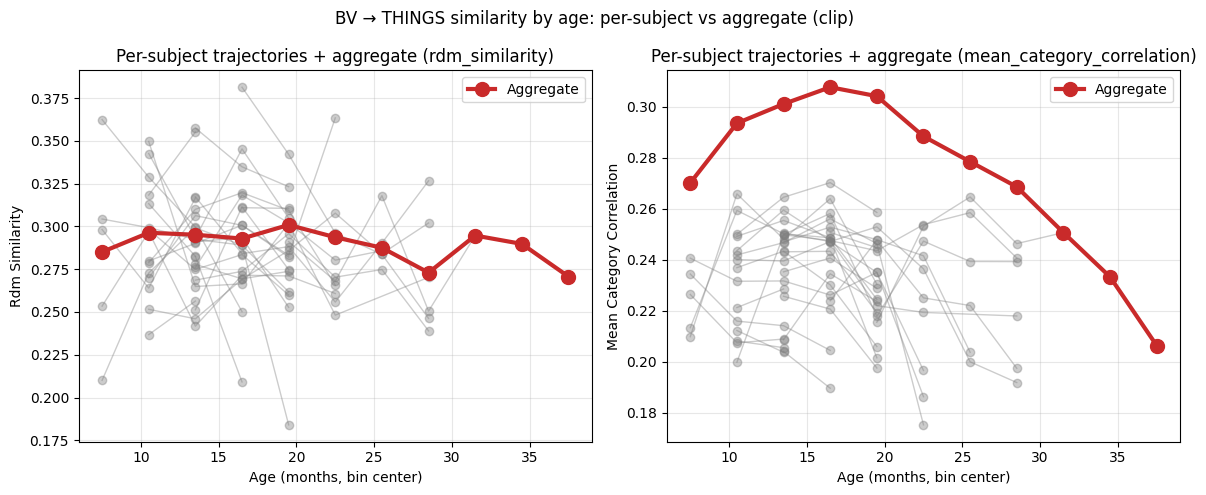

In [19]:
# Plot 1: Per-subject trajectories (thin lines) + aggregate (thick line)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, metric in zip(axes, ["rdm_similarity", "mean_category_correlation"]):
    for subject_id in df_per_subject["subject_id"].unique():
        sub = df_per_subject[df_per_subject["subject_id"] == subject_id].sort_values("age_center")
        if len(sub) == 0:
            continue
        # Drop NaN for clean line (optional: keep and matplotlib will break lines)
        sub_clean = sub.dropna(subset=[metric])
        if len(sub_clean) < 2:
            continue
        ax.plot(sub_clean["age_center"], sub_clean[metric], "o-", alpha=0.4, linewidth=1, color="gray", label="_nolegend_")
    valid = df_results[metric].notna()
    ax.plot(df_results.loc[valid, "age_center"], df_results.loc[valid, metric], "o-", color="#c92a2a", linewidth=3, markersize=10, label="Aggregate")
    ax.set_xlabel("Age (months, bin center)")
    ax.set_ylabel(metric.replace("_", " ").title())
    ax.set_title(f"Per-subject trajectories + aggregate ({metric})")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)
plt.suptitle(f"BV → THINGS similarity by age: per-subject vs aggregate ({EMBEDDING_TYPE})", fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS_OUTPUT_DIR / "bv_similarity_to_things_per_subject_trajectories.pdf", bbox_inches="tight")
plt.savefig(PLOTS_OUTPUT_DIR / "bv_similarity_to_things_per_subject_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()

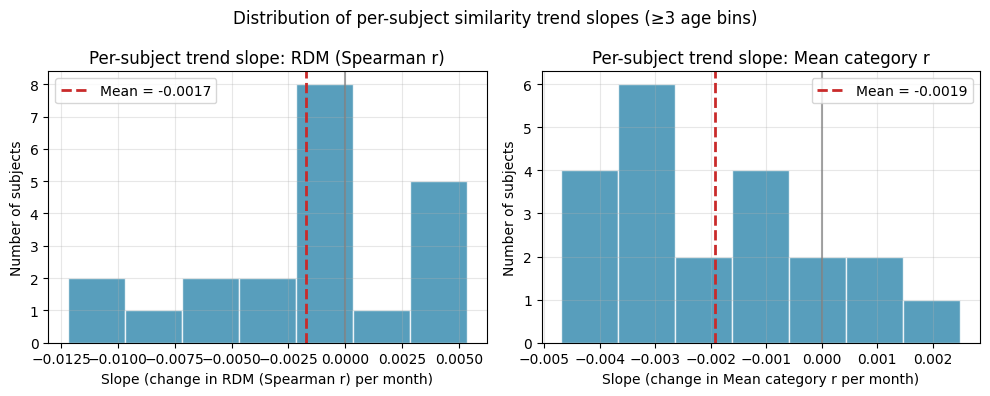

In [20]:
# Plot 2: Distribution of per-subject slopes (similarity change per month)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, label in zip(axes, ["slope_rdm", "slope_mean_cat"], ["RDM (Spearman r)", "Mean category r"]):
    slopes = df_subject_trends[col].dropna()
    if len(slopes) > 0:
        ax.hist(slopes, bins=min(15, max(5, len(slopes)//3)), color="#2e86ab", alpha=0.8, edgecolor="white")
        ax.axvline(slopes.mean(), color="#c92a2a", linestyle="--", linewidth=2, label=f"Mean = {slopes.mean():.4f}")
        ax.axvline(0, color="gray", linestyle="-", alpha=0.7)
    ax.set_xlabel(f"Slope (change in {label} per month)")
    ax.set_ylabel("Number of subjects")
    ax.set_title(f"Per-subject trend slope: {label}")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)
plt.suptitle(f"Distribution of per-subject similarity trend slopes (≥{MIN_AGE_BINS_FOR_TREND} age bins)", fontsize=12)
plt.tight_layout()
plt.savefig(PLOTS_OUTPUT_DIR / "bv_similarity_to_things_per_subject_slopes.pdf", bbox_inches="tight")
plt.savefig(PLOTS_OUTPUT_DIR / "bv_similarity_to_things_per_subject_slopes.png", dpi=150, bbox_inches="tight")
plt.show()

## Data coverage: number of shared categories per age bin

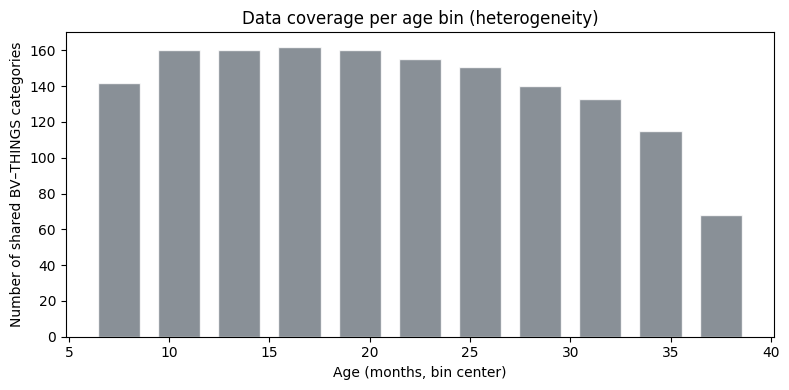

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(df_results["age_center"], df_results["n_shared_categories"], width=AGE_BIN_SIZE_MONTHS * 0.7, color="#6c757d", alpha=0.8, edgecolor="white")
ax.set_xlabel("Age (months, bin center)")
ax.set_ylabel("Number of shared BV–THINGS categories")
ax.set_title("Data coverage per age bin (heterogeneity)")
plt.tight_layout()
plt.show()